Ex. 1. Scrieţi un program în Python care să preia ca input un fişier .csv cu o listă oarecare şi să aibă ca output un număr
predeterminat de elemente din acea listă, fără repetiţie. Aplicaţi pe lista studenţilor din grupa dumneavoastră care nu
au prezentat încă o temă.

Notă: Pentru generarea unui eşantion aleator se poate apela funcţia sample din modulul random sau funcţia ran-
dom.choice cu argumentul replace=False din librăria Numpy.

In [ ]:
import csv
import random

def selectKEntries(file_path, k):
    entries = []
    
    with open(file_path, mode='r', encoding='utf-8') as f:
        r = csv.reader(f)
        for line in r:
            if line:
                entries.append(line[0])
    
    if k > len(entries):
        raise f"Nr cerut ({k}) este mai mare decat nr de intrari din csv disponibile ({len(entries)})."
    
    selected = random.sample(entries, k)
    return selected

Ex. 2. Doi prieteni joacă următorul joc, după următoarele reguli:
Pasul 1. Primul jucător aruncă cu o monedă.
● Dacă pică stemă, cel de-al doilea trebuie să arunce cu zarul şi să-i dea primului o sumă egală z − 3$, unde z
este rezultatul aruncării cu zarul (a da o sumă negativă este echivalent cu a lua opusul acelei sume). Jocul
se încheie aici.
● Dacă pică ban, atunci primul jucător trebuie să-i dea celui de-al doilea 0.5 $.
Pasul n. În caz că jocul nu s-a încheiat, se reia pasul 1.
Astfel, jocul se opreşte la pasul corespunzător obţinerii stemei de către primul jucător.
a) Ce fel de distribuţie urmează N, numărul de paşi ai jocului?
b) Simulaţi în Python un astfel de joc. Variabilele care ne interesează sunt N şi suma totală S pe care cel de-al
doilea jucător trebuie să i-o dea primului.
c) Prin simularea unui număr mare de astfel de jocuri, determinaţi cu aproximaţie media lui S şi reprezentaţi grafic
(printr-o histogramă) distribuţia acesteia.
d) Ce se întâmplă dacă moneda este măsluită? Încercaţi să refaceţi pct. c) cu o probabilitate de apariţie a stemei
p = 0.3, respectiv p = 0.7.

a) Distribuția lui N
Numărul de pași $N$ reprezintă numărul de aruncări ale monedei până la obținerea primei steme (inclusiv pasul în care cade stema). Având în vedere că evenimentele (aruncările) sunt independente, variabila aleatoare $N$ urmează o distribuție geometrică cu parametrul $p$ (unde $p$ este probabilitatea de a obține stemă). Pentru o monedă corectă, $p = 0.5$.

In [1]:
# b)

import numpy as np
import matplotlib.pyplot as plt

def simuleaza_joc(p=0.5):
    """
    Simulează un singur joc. 
    p = probabilitatea de a pica stemă
    Returnează: (N, S)
    """
    N = 0
    S = 0
    while True:
        N += 1
        if np.random.rand() < p:  # Cazul 'Stemă'
            z = np.random.randint(1, 7) # Zarul: 1, 2, 3, 4, 5, 6
            S += (z - 3)
            break
        else:                     # Cazul 'Ban'
            S -= 0.5
    return N, S

In [2]:
def simuleaza_N_jocuri(numar_jocuri=10000, p=0.5):
    """Rulează un număr mare de jocuri pentru a estima distribuția lui S."""
    rezultate_S = []
    
    for _ in range(numar_jocuri):
        _, S = simuleaza_joc(p)
        rezultate_S.append(S)
        
    media_S = np.mean(rezultate_S)
    return rezultate_S, media_S

Media lui S pentru p=0.5: 0.002 (Așteptat: ~0.000)
Media lui S pentru p=0.3: -0.665 (Așteptat: ~-0.667)
Media lui S pentru p=0.7: 0.258 (Așteptat: ~0.286)


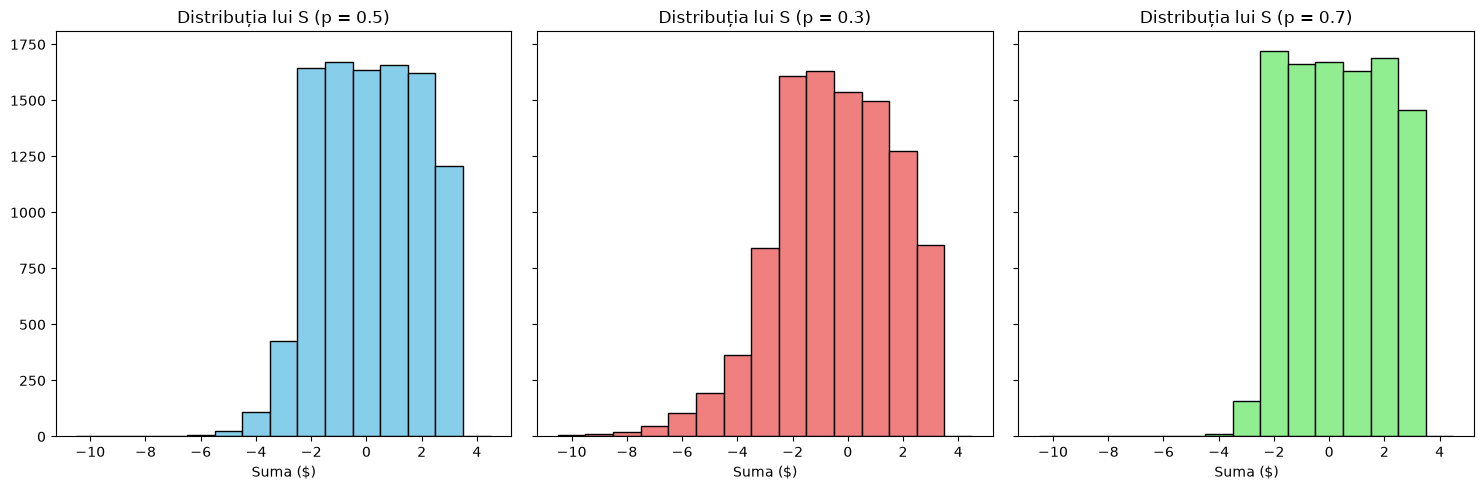

In [3]:
# c)
S_05, media_05 = simuleaza_N_jocuri(10000, p=0.5)
print(f"Media lui S pentru p=0.5: {media_05:.3f} (Așteptat: ~0.000)")

# d)
S_03, media_03 = simuleaza_N_jocuri(10000, p=0.3)
print(f"Media lui S pentru p=0.3: {media_03:.3f} (Așteptat: ~-0.667)")

S_07, media_07 = simuleaza_N_jocuri(10000, p=0.7)
print(f"Media lui S pentru p=0.7: {media_07:.3f} (Așteptat: ~0.286)")

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
bins = np.arange(-10.5, 5.5, 1)

axs[0].hist(S_05, bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title('Distribuția lui S (p = 0.5)')
axs[0].set_xlabel('Suma ($)')

axs[1].hist(S_03, bins=bins, color='lightcoral', edgecolor='black')
axs[1].set_title('Distribuția lui S (p = 0.3)')
axs[1].set_xlabel('Suma ($)')

axs[2].hist(S_07, bins=bins, color='lightgreen', edgecolor='black')
axs[2].set_title('Distribuția lui S (p = 0.7)')
axs[2].set_xlabel('Suma ($)')

plt.tight_layout()
plt.show()

Ex. 3. Într-o frizerie, trei frizeri îşi tund clienţii cu următoarele viteze medii: primul cu 3 clienţi pe oră, al doilea cu 6 pe
oră iar al treilea cu 4 pe oră. Astfel, timpul de servire al unui client este modelat de distribuţii exponenţiale cu parametrii
λ1 = 3 h−1
, λ2 = 6 h−1
, respectiv λ3 = 4 h−1

, iar probabilităţile de preluare a unui client de către un anumit frizer sunt

3/13, 6/13, respectiv 4/13 (de ce?). Fie X timpul de servire pentru un client.
Generaţi 10000 de valori pentru X, şi în felul acesta estimaţi media şi deviaţia standard a lui X. Realizaţi un grafic
aproximativ al densităţii distribuţiei lui X.
Notă: Distribuţia Exp(λ) se poate apela prin random.exponential(scale=1/λ) în Numpy, sau cu stats.expon(scale=1/λ)
în Scipy. Având în vedere că X are o distribuţie continuă, densitatea aproximativă acesteia se poate vizualiza folosind
funcţia plot_kde din librăria Arviz.

In [1]:
import numpy as np
import matplotlib
matplotlib.use("QtAgg")
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

N_esantioane = 10000
lambdas = [3.0, 6.0, 4.0]
probabilitati = [3/13, 6/13, 4/13]

frizeri_alesi = np.random.choice([0, 1, 2], size=N_esantioane, p=probabilitati)
X = np.array([np.random.exponential(scale=1/lambdas[f]) for f in frizeri_alesi])

media_X = np.mean(X)
std_X = np.std(X)

print(f"Media estimata a lui X: {media_X:.4f} ore ({media_X * 60:.2f} minute)")
print(f"Deviatia standard estimata a lui X: {std_X:.4f} ore")

kde = gaussian_kde(X)
x_grid = np.linspace(0, np.max(X), 1000)

plt.plot(x_grid, kde(x_grid), label="Densitate estimata a lui X (KDE)", color="crimson", lw=2)
plt.xlabel("Timpul de servire X (ore)")
plt.ylabel("Densitate")
plt.title("Estimarea densitatii distributiei timpului de servire X")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Media estimata a lui X: 0.2308 ore (13.85 minute)
Deviatia standard estimata a lui X: 0.2474 ore
